In [1]:
import os
import pandas as pd
from skimage import transform
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from skimage import color
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr
import copy

from CV_CNN_regressor.CV_CNN_regressor import ImageDataset, CNNRegressorCV, evaluate, get_feature

In [2]:
# Load training and oos dataset
image_tensors = []
number = []
image_folder = '/Users/chenxinran/Desktop/CV-CNN/CobaltImageDataset/cv_mixture_Co' 
for filename in os.listdir(image_folder):
    if filename.endswith('.png'):
        num = filename.split('.')[0]
        num = int(num)
        number.append(num)
        img = Image.open(os.path.join(image_folder, filename))
        img_array = np.array(img)
        
        if img_array.ndim == 3:
            if img_array.shape[2] == 4:
                rgb_img = color.rgba2rgb(img_array)
                gray_img = color.rgb2gray(rgb_img)
            elif img_array.shape[2] == 3:
                gray_img = color.rgb2gray(img_array)
            else:
                raise ValueError(f"Unsupported channel shape: {img_array.shape}")
        elif img_array.ndim == 2:
            gray_img = img_array 
        else:
            raise ValueError(f"Unsupported image shape: {img_array.shape}")
            
        new_size = (300, 300)
        resized_img = transform.resize(gray_img, new_size)
        img_tensor = torch.tensor(resized_img)
        img_tensor = torch.tensor(resized_img, dtype=torch.float32).unsqueeze(0)
        image_tensors.append(img_tensor)

image_tensors_oos = []
number_oos = []
image_folder_oos = '/Users/chenxinran/Desktop/CV-CNN/CobaltImageDataset/cv_mixture_Co_oos' 
for filename in os.listdir(image_folder_oos):
    if filename.endswith('.png'):
        num = filename.split('.')[0]
        num = int(num)
        number_oos.append(num)
        img = Image.open(os.path.join(image_folder_oos, filename))
        img_array = np.array(img)
        if len(img_array.shape) == 3:
            #print(num)
            rgb_image = color.rgba2rgb(img)
            gray_img = color.rgb2gray(rgb_image)
            img_array = np.array(gray_img)
        new_size = (300, 300)
        resized_img = transform.resize(img_array, new_size)
        img_tensor = torch.tensor(resized_img)
        img_tensor = img_tensor.to(torch.float32)
        image_tensors_oos.append(img_tensor)

df = pd.read_csv('/Users/chenxinran/Desktop/CV-CNN/CobaltImageDataset/data_Co.csv')
target = df['yield'].to_list()
target = np.array(target)

num_csv = df['number_in_file'].to_list()
num_csv = np.array(num_csv)

num_csv_orig = df['orig_img_num'].to_list()
num_csv_orig = np.array(num_csv_orig)

df_oos = pd.read_csv('/Users/chenxinran/Desktop/CV-CNN/CobaltImageDataset/data_Co_oos.csv')
target_oos = df_oos['yield'].to_list()
target_oos = np.array(target_oos)

num_csv_oos = df_oos['number_in_file'].to_list()
num_csv_oos = np.array(num_csv_oos)

num_csv_orig_oos = df_oos['orig_img_num'].to_list()
num_csv_orig_oos = np.array(num_csv_orig_oos)

target_dict = {}
for idx, y in zip(num_csv, target):
    target_dict[idx] = y

target_train = []
for i in number:
    y = target_dict[i]
    target_train.append(y)    
target_train = np.array(target_train)

orig_img_num_dict = {}
for idx, y in zip(num_csv, num_csv_orig):
    orig_img_num_dict[idx] = y

orig_img_num_train = []
for i in number:
    y = orig_img_num_dict[i]
    orig_img_num_train.append(y)
orig_img_num_train = np.array(orig_img_num_train)

target_dict_oos = {}
for idx, y in zip(num_csv_oos, target_oos):
    target_dict_oos[idx] = y

target_oos = []
for i in number_oos:
    y = target_dict_oos[i]
    target_oos.append(y)    
target_oos = np.array(target_oos)

orig_img_num_dict_oos = {}
for idx, y in zip(num_csv_oos, num_csv_orig_oos):
    orig_img_num_dict_oos[idx] = y

orig_img_num_oos = []
for i in number_oos:
    y = orig_img_num_dict_oos[i]
    orig_img_num_oos.append(y)
orig_img_num_oos = np.array(orig_img_num_oos)

dataset_f = ImageDataset(image_tensors, number, target_train, orig_img_num_train)
data_loader_f = DataLoader(dataset_f, batch_size=5, shuffle=True)

dataset_oos = ImageDataset(image_tensors_oos, number_oos, target_oos, orig_img_num_oos)
data_loader_oos = DataLoader(dataset_oos, batch_size=1, shuffle=False)

In [4]:
# Model training
all_indices = list(range(len(dataset_f)))
train_idx, val_idx = train_test_split(
    all_indices,
    test_size=0.1,
    random_state=0,
    shuffle=True
)
train_dataset = [dataset_f[i] for i in train_idx]
val_dataset   = [dataset_f[i] for i in val_idx]
train_loader = DataLoader(train_dataset, batch_size=5, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=5, shuffle=False)

model = CNNRegressorCV()
criterion_r = nn.MSELoss()
optimizer_r = optim.Adam(model.parameters(),lr=0.001)    
num_val_list = []
acc_val_list= []
loss_list = []
r2_list = []
best_loss = float('inf')
best_state = None
training_epoch = 100
for epoch in range(training_epoch):
    model.train()
    for image, num, label, orig_num in train_loader:
        optimizer_r.zero_grad()
        output, _, _ = model(image)
        output = output.view(-1).to(torch.float64)
        label = label.view(-1).to(torch.float64)
        loss = criterion_r(output, label)
        loss.backward()
        optimizer_r.step()
    model.eval()
    with torch.no_grad():
        label_val, prediction_val, num_val, orig_num_val = evaluate(model, val_loader)
        attention_val, atten_num_val, attention2_val = get_feature(model, val_loader)
        prediction_val = torch.tensor(np.array(prediction_val), dtype=torch.float64).view(-1)
        label_val = torch.tensor(np.array(label_val), dtype=torch.float64).view(-1)
        loss_val = criterion_r(prediction_val, label_val)
    
    loss_val = loss_val.detach()
    loss_list.append(loss_val)
    if loss_val < best_loss:
        best_loss = loss_val
        best_state = copy.deepcopy(model.state_dict())
    if epoch == training_epoch-1 :
        print("Training END")

Training END


After average of augmented entry: Pearson R 0.8960, MAE 0.3266


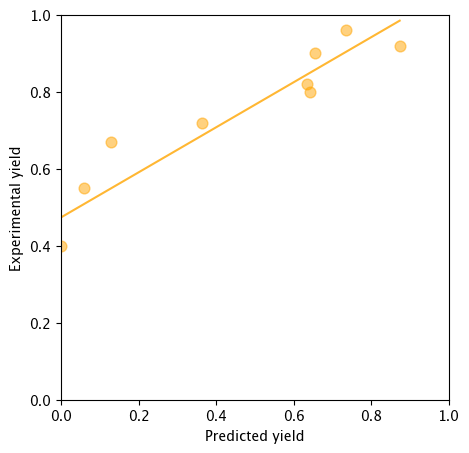

In [7]:
# Out-of-sample test
label_oos, prediction_oos, num_oos, orig_num_oos = evaluate(model, data_loader_oos)
label_oos = np.array(label_oos).astype(float)
prediction_oos = np.array(prediction_oos).astype(float)
num_oos = np.array(num_oos).astype(int)
orig_num_oos = np.array(orig_num_oos).astype(int)

aug_dict_oos = {}
label_dict_oos = {}
for idx, num in enumerate(num_oos):
    orig_idx = orig_num_oos[idx]
    if orig_idx not in aug_dict_oos:
        aug_dict_oos[orig_idx] = []
        label_dict_oos[orig_idx] = []
    aug_dict_oos[orig_idx].append(prediction_oos[idx])
    label_dict_oos[orig_idx].append(label_oos[idx])

avg_aug_list_oos = []
avg_label_list_oos = []
for k in aug_dict_oos:
    avg_aug_list_oos.append(np.mean(aug_dict_oos[k]))
    avg_label_list_oos.append(label_dict_oos[k][0])

avg_aug_oos = np.array(avg_aug_list_oos)
avg_label_oos = np.array(avg_label_list_oos)
    
pearson_r_avg_oos, _ = pearsonr(avg_label_oos, avg_aug_oos)   
mae_avg_oos = mean_absolute_error(avg_label_oos, avg_aug_oos)    
print("After average of augmented entry: Pearson R {:.4f}, MAE {:.4f}".format(pearson_r_avg_oos, mae_avg_oos))

prediction_oos = np.array([x[0] for x in prediction_oos], dtype=float)

plt.figure(figsize=(5, 5), dpi=100)
plt.scatter(avg_aug_oos, avg_label_oos, color='orange', alpha=0.5, s=60)
coefficients = np.polyfit(avg_aug_oos, avg_label_oos, 1)
polynomial = np.poly1d(coefficients)
x_fit = np.linspace(min(avg_aug_oos), max(avg_aug_oos), 100)
y_fit = polynomial(x_fit)

plt.plot(x_fit, y_fit, color='orange', alpha=0.8)
plt.xlabel('Predicted yield')
plt.ylabel('Experimental yield')
plt.ylim(0,1)
plt.xlim(0,1)
plt.show()